# Setup and Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../Datasets/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


# Initial Data Exploration

In [4]:
print("Shape of dataset:", df.shape)
df.describe()

Shape of dataset: (1000, 3)


,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


# Visualizing Distributions (Before)

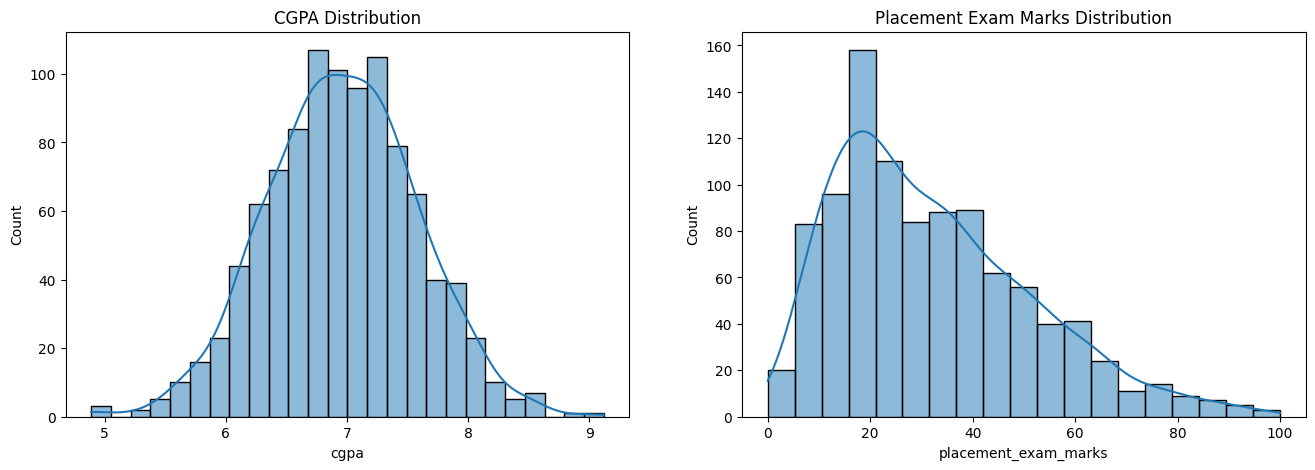

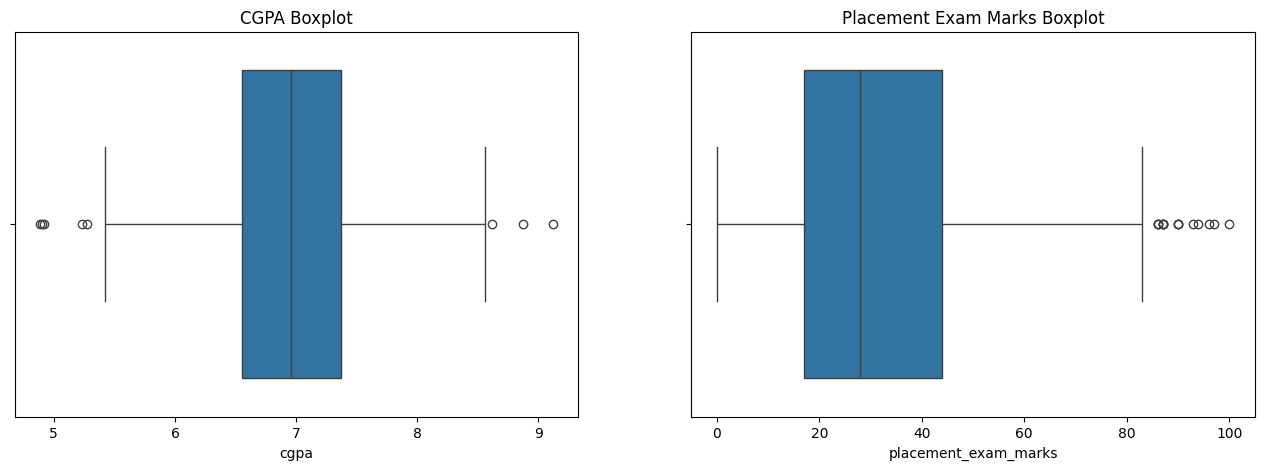

In [5]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df["cgpa"], kde=True)
plt.title("CGPA Distribution")

plt.subplot(1,2,2)
sns.histplot(df["placement_exam_marks"], kde=True)
plt.title("Placement Exam Marks Distribution")
plt.show()

plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.boxplot(x=df["cgpa"])
plt.title("CGPA Boxplot")

plt.subplot(1,2,2)
sns.boxplot(x=df["placement_exam_marks"])
plt.title("Placement Exam Marks Boxplot")
plt.show()

# Calculating Z-Scores & Identifying Outliers

In [6]:
df["cgpa_zscore"] = (df["cgpa"] - df["cgpa"].mean()) / df["cgpa"].std()

outliers = df[(df["cgpa_zscore"] > 3) | (df["cgpa_zscore"] < -3)]
outliers

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


# Removing Outliers

In [7]:
new_df = df[(df["cgpa_zscore"] < 3) & (df["cgpa_zscore"] > -3)]
print("Original shape:", df.shape)
print("New shape:", new_df.shape)

Original shape: (1000, 4)
New shape: (995, 4)


# Side-by-Side Comparison

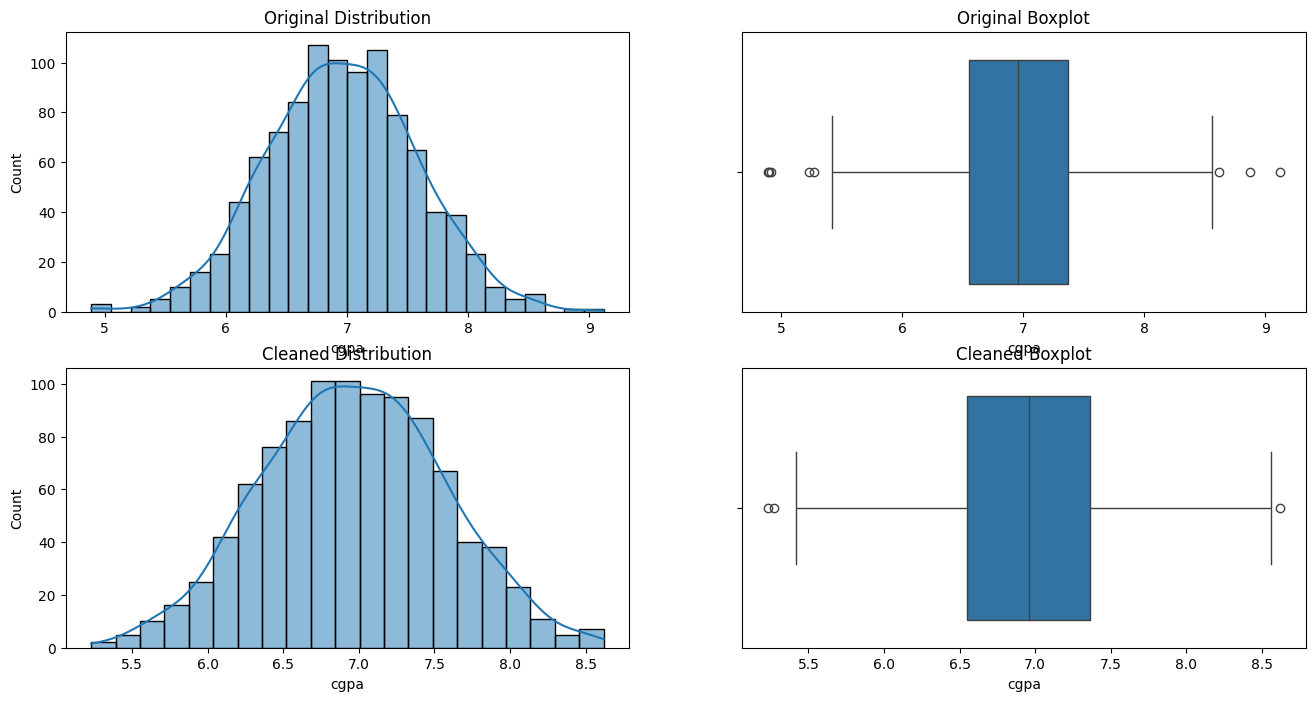

In [8]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df["cgpa"], kde=True)
plt.title("Original Distribution")

plt.subplot(2,2,2)
sns.boxplot(x=df["cgpa"])
plt.title("Original Boxplot")

plt.subplot(2,2,3)
sns.histplot(new_df["cgpa"], kde=True)
plt.title("Cleaned Distribution")

plt.subplot(2,2,4)
sns.boxplot(x=new_df["cgpa"])
plt.title("Cleaned Boxplot")
plt.show()